# Detecting Structural Distress at Scale
### A Geospatial Foundation Model Approach to Urban Building Safety

**Course:** MUSA 6500 – Geospatial Machine Learning in Remote Sensing  
**Authors:** Jason Fan, Henry Sywulak-Herr

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Environment setup & imports |
| 2 | Data loading (imagery, footprints, labels, elevation) |

---
## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import show as rshow

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Add project root to path so loader scripts are importable ──────────────
PROJECT_ROOT = Path('.').resolve()   # adjust if notebook is in a sub-folder
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Device: cpu
Project root: F:\GitHub\musa6500-finalproject


---
## 2. Data Loading

Each dataset is loaded via its own dedicated module.  

### Imagery

In [2]:
from load_imagery import open_imagery

# This creates a lazy DataArray backed by the remote Cloud Optimized GeoTIFF (COG)
src = open_imagery()

[load_imagery] Opened: https://musa-650.s3.amazonaws.com/phl_aerial_0.3m.tif
  CRS   : EPSG:2272
  Shape : (3, 123383, 109972)  (bands × rows × cols)
  Res   : (0.984252, -0.984252) (x_res, y_res)


### Parcels & Permits

In [3]:
from load_building_footprints import load_building_footprints, fetch_geojson
from pathlib import Path

VECTOR_DIR = Path('data/vector')
CRS = 'EPSG:2272'

# PWD parcels (primary geometry for all spatial joins)
parcels = load_building_footprints()
print(f'Parcels: {len(parcels):,}')

# eCLIPSE permits – used to filter false positives (new construction)
PERMIT_URL = 'https://hub.arcgis.com/api/v3/datasets/8d18914ff740444793937d8724c64da8_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1'
permits = fetch_geojson('permits', PERMIT_URL, VECTOR_DIR).to_crs(CRS)
print(f'Permits: {len(permits):,}')

[load_building_footprints] Loading parcels from cache: data\vector\parcels.geojson
[load_building_footprints] Geometry cleaning: 547,290 → 547,280 parcels
[load_building_footprints] Parcels loaded: 547,280 | CRS: EPSG:2272
Parcels: 547,280
[load_building_footprints] Loading permits from cache: data\vector\permits.geojson
Permits: 13,902


### Training Labels (L&I Violations)

Fetching imm_dang...
[load_labels] Loading imm_dang from cache: data\labels\imm_dang.geojson
  rows: 139
Fetching unsafe...
[load_labels] Loading unsafe from cache: data\labels\unsafe.geojson
  rows: 2,629
Fetching clean_seal...
[load_labels] Loading clean_seal from cache: data\labels\clean_seal.geojson
  rows: 8,564
Labeled Imminently Dangerous : 136
Labeled Unsafe               : 7,794
Labeled Stable               : 539,350


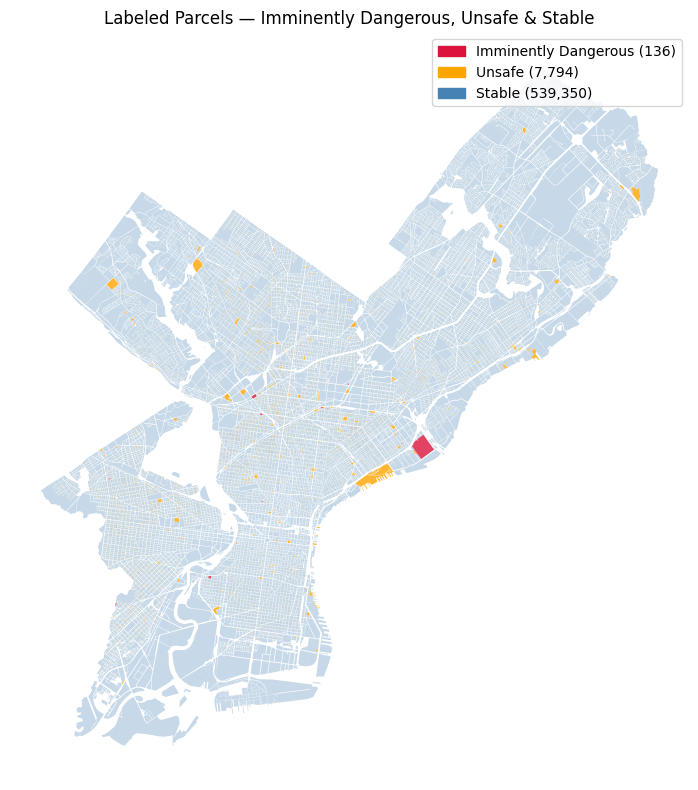

In [4]:
import importlib
import load_labels
importlib.reload(load_labels)

from load_labels import load_labels, plot_labels

parcels_labeled = load_labels(parcels, permits=permits)

plot_labels(parcels_labeled)

Labeled Imminently Dangerous : 136
Labeled Unsafe               : 7,794
Labeled Stable               : 539,360

"Imminently dangerous" is too small of a sample for the deep learning model to learn distinct classes. Will be merging unsafe and ID into a single "distressed" class. 

### Create balanced df

In [5]:
import pandas as pd

# 1. Isolate all the minority class parcels (Unsafe and Imminently Dangerous)
distressed_parcels = parcels_labeled[parcels_labeled['label'].isin([1, 2])].copy()

# 2. Randomly sample the "Stable" (0) class. 
# Let's take twice as many Stable as Distressed (a 2:1 ratio is a good starting point)
num_distressed = len(distressed_parcels)
num_stable_to_keep = num_distressed * 2

print(f"Keeping {num_distressed} distressed parcels and {num_stable_to_keep} stable parcels.")

# Sample from the stable parcels
stable_parcels = parcels_labeled[parcels_labeled['label'] == 0].sample(
    n=num_stable_to_keep, 
    random_state=42 # Set random state for reproducibility
).copy()

# 3. Combine them and shuffle the dataset
balanced_parcels = pd.concat([distressed_parcels, stable_parcels])
balanced_parcels = balanced_parcels.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nNew Balanced Label Counts:")
print(balanced_parcels['label'].value_counts())

Keeping 7930 distressed parcels and 15860 stable parcels.

New Balanced Label Counts:
label
0    15860
1     7794
2      136
Name: count, dtype: int64


Label merge

In [6]:
# Map Imminently Dangerous (2) to Unsafe/Distressed (1)
balanced_parcels['label'] = balanced_parcels['label'].replace({2: 1})

print("Final Binary Label Counts (0=Stable, 1=Distressed):")
print(balanced_parcels['label'].value_counts())

Final Binary Label Counts (0=Stable, 1=Distressed):
label
0    15860
1     7930
Name: count, dtype: int64


In [7]:
# Run this locally BEFORE going to Colab
balanced_parcels[["geometry", "label"]].to_file("data/balanced_parcels.geojson", driver="GeoJSON")

### Focal Loss:

weighted cross entropy is the standard fix but focal loss is better for is our model struggles to recognize the visual signs of decay. 

In [13]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: raw predictions from your model (logits)
        # targets: actual labels (0, 1, or 2)
        
        # Calculate standard cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # pt is the probability the model assigned to the CORRECT class
        pt = torch.exp(-ce_loss) 
        
        # Calculate Focal Loss
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Initialize it to use in your training loop
criterion = FocalLoss(gamma=2.0)

### Image augmentation 
this helps oversample the distressed buildings 

In [24]:
import torchvision.transforms as T

# Standard size for most vision foundation models
IMAGE_SIZE = (224, 224) 

train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(IMAGE_SIZE), # Force consistent size
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=(0, 360)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
])

# Validation transforms should NEVER have random augmentations
val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize(IMAGE_SIZE),
    T.ToTensor(),
])

pytorch dataset class

In [37]:
# --- Create a new cell for the Dataset Class ---
from load_imagery import read_parcel_chip

class ParcelDataset(Dataset):
    def __init__(self, gdf, imagery_src, transform=None):
        # Reset index to ensure iloc works cleanly
        self.gdf = gdf.reset_index(drop=True)
        self.src = imagery_src
        self.transform = transform

    def __len__(self):
        return len(self.gdf)

    def __getitem__(self, idx):
        row = self.gdf.iloc[idx]
        label = row.label
        original_idx = row.name  # the original DataFrame index used as filename

        chip_path = CHIP_DIR / f"{original_idx}.npy"
        try:
            arr = np.load(chip_path)  # [3, H, W], float32
            # Normalize to [0, 1]
            arr = np.clip(arr / (arr.max() + 1e-8), 0, 1)
            img_data = (arr * 255).astype(np.uint8).transpose(1, 2, 0)  # [H, W, 3]
        except Exception:
            img_data = np.zeros((224, 224, 3), dtype=np.uint8)

        if self.transform:
            img_tensor = self.transform(img_data)

        return img_tensor, torch.tensor(label, dtype=torch.long)

Helper function:

In [29]:
from torch.utils.data import DataLoader

def create_dataloaders(train_gdf, val_gdf, src, train_tfm, val_tfm, batch_size=32):
    """Creates and returns a dictionary of train and val dataloaders."""
    datasets = {
        'train': ParcelDataset(train_gdf, src, transform=train_tfm),
        'val': ParcelDataset(val_gdf, src, transform=val_tfm)
    }
    loaders = {
        'train': DataLoader(datasets['train'], batch_size=batch_size, shuffle=True, drop_last=True),
        'val': DataLoader(datasets['val'], batch_size=batch_size, shuffle=False)
    }
    return loaders

train/validation split

In [ ]:
# --- Create a new cell for DataLoaders ---
from sklearn.model_selection import train_test_split

# Split the data (80% Train, 20% Validation)
# stratify=True ensures the 2:1 ratio is preserved in both sets
train_gdf, val_gdf = train_test_split(
    balanced_parcels, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=balanced_parcels['label']
)

print(f"Training parcels: {len(train_gdf)}")
print(f"Validation parcels: {len(val_gdf)}")

# Instantiate Datasets
train_dataset = ParcelDataset(train_gdf, src, transform=train_transforms)
val_dataset = ParcelDataset(val_gdf, src, transform=val_transforms)

# Create DataLoaders (Batches)
BATCH_SIZE = 32

#This section requires it to be run with a NVIDIA GPU or colab which has it for free
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, num_workers=4, pin_memory=(DEVICE == 'cuda')
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=(DEVICE == 'cuda')
)

# Quick test to make sure the pipeline works
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch label shape: {labels.shape}") # Should be [32]

Training parcels: 19032
Validation parcels: 4758


CLAY model

download checkpoint

In [32]:
import urllib.request
from pathlib import Path

CKPT_PATH = Path("data/clay-v1.5.ckpt")
CKPT_URL  = "https://huggingface.co/made-with-clay/Clay/resolve/main/v1.5/clay-v1.5.ckpt"

if not CKPT_PATH.exists():
    CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading Clay v1.5 checkpoint (~3 GB)…")
    urllib.request.urlretrieve(CKPT_URL, CKPT_PATH)
    print(f"Saved to {CKPT_PATH}")
else:
    print(f"Checkpoint already exists: {CKPT_PATH}")

Saved to data\clay-v1.5.ckpt


build the classifer

In [33]:
import re
import torch
import torch.nn as nn
from claymodel.model import Encoder

# ── RGB wavelengths (micrometers) for Philadelphia aerial imagery ──────────
RGB_WAVES = torch.tensor([0.665, 0.560, 0.493])   # R, G, B
RGB_GSD   = torch.tensor(0.3)                      # Philadelphia aerial ~0.3 m

class ClayDistressClassifier(nn.Module):
    """
    Clay v1.5 large encoder (frozen) + 2-class MLP head.
    Mirrors claymodel/finetune/classify/factory.py but wired for 3-band
    aerial RGB instead of 10-band Sentinel-2.
    """
    def __init__(self, num_classes=2, ckpt_path=None):
        super().__init__()

        # Clay large encoder — mask_ratio=0, shuffle=False for inference/fine-tune
        self.encoder = Encoder(
            mask_ratio=0.0,
            patch_size=8,
            shuffle=False,
            dim=1024,
            depth=24,
            heads=16,
            dim_head=64,
            mlp_ratio=4.0,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(1024),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, num_classes),
        )

        if ckpt_path:
            self._load_clay_weights(ckpt_path)

    def _load_clay_weights(self, ckpt_path):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(ckpt_path, map_location=device)
        state_dict = ckpt.get("state_dict", ckpt)

        # Strip the "model.encoder." prefix used in the Lightning checkpoint
        encoder_sd = {
            re.sub(r"^model\.encoder\.", "", k): v
            for k, v in state_dict.items()
            if k.startswith("model.encoder")
        }

        missing = []
        for name, param in self.encoder.named_parameters():
            if name in encoder_sd and param.size() == encoder_sd[name].size():
                param.data.copy_(encoder_sd[name])
            else:
                missing.append(name)

        if missing:
            print(f"  [warn] {len(missing)} encoder params not loaded: {missing[:5]}…")
        else:
            print("  Clay encoder weights loaded successfully.")

        # Freeze encoder — only the head trains
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.encoder.eval()

    def forward(self, pixels):
        """
        pixels : Float tensor [B, 3, 224, 224] normalised to [0, 1]
        """
        B = pixels.shape[0]
        device = pixels.device

        datacube = {
            "pixels": pixels,
            "time":   torch.zeros(B, 4, device=device),   # unknown → zeros
            "latlon": torch.zeros(B, 4, device=device),   # unknown → zeros
            "gsd":    RGB_GSD.to(device),
            "waves":  RGB_WAVES.to(device),
        }

        # encoder returns (embeddings, unmasked_idx, masked_idx)
        embeddings, *_ = self.encoder(datacube)  # [B, 1+patches, 1024]
        cls_token = embeddings[:, 0, :]           # [B, 1024]
        return self.head(cls_token)               # [B, 2]


model = ClayDistressClassifier(num_classes=2, ckpt_path=CKPT_PATH).to(DEVICE)
print(model)
print(f"\nTrainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Frozen params:    {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

  Clay encoder weights loaded successfully.
ClayDistressClassifier(
  (encoder): Encoder(
    (patch_embedding): DynamicEmbedding(
      (weight_generator): WavesTransformer(
        (encoder): TransformerEncoder(
          (layers): ModuleList(
            (0): TransformerEncoderLayer(
              (self_attn): MultiheadAttention(
                (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
              )
              (linear1): Linear(in_features=128, out_features=2048, bias=True)
              (dropout): Dropout(p=0, inplace=False)
              (linear2): Linear(in_features=2048, out_features=128, bias=True)
              (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (dropout1): Dropout(p=0, inplace=False)
              (dropout2): Dropout(p=0, inplace=False)
            )
          )
        )
        (fc_weight): Linear(in_fea

Pre-cache to disk

In [35]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

CHIP_DIR = Path("data/chips")
CHIP_DIR.mkdir(parents=True, exist_ok=True)

def precache_chips(gdf, src, chip_dir=CHIP_DIR):
    """Clip and save every parcel chip once. Skips already-saved chips."""
    for idx, row in tqdm(gdf.iterrows(), total=len(gdf), desc="Caching chips"):
        out = chip_dir / f"{idx}.npy"
        if out.exists():
            continue
        try:
            chip = read_parcel_chip(src, row.geometry)
            arr = chip.values[:3, :, :].astype(np.float32)
            np.save(out, arr)
        except Exception:
            np.save(out, np.zeros((3, 64, 64), dtype=np.float32))

precache_chips(balanced_parcels, src)

Caching chips: 100%|██████████| 23790/23790 [37:40<00:00, 10.52it/s] 


train loop

In [34]:
from sklearn.metrics import recall_score, precision_score, classification_report

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

NUM_EPOCHS = 20
best_recall = 0.0

for epoch in range(NUM_EPOCHS):
    # ── Train ────────────────────────────────────────────────────────────
    model.train()
    model.encoder.eval()          # keep BN/dropout in encoder frozen
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    recall    = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
    precision = precision_score(all_labels, all_preds, pos_label=1, zero_division=0)
    scheduler.step()

    print(f"Epoch {epoch+1:02d} | loss {train_loss/len(train_loader):.4f} "
          f"| recall {recall:.3f} | precision {precision:.3f}")

    if recall > best_recall:
        best_recall = recall
        torch.save(model.state_dict(), "data/best_model.pt")
        print(f"  → saved (best recall so far: {best_recall:.3f})")

print("\nFinal validation report:")
print(classification_report(all_labels, all_preds, target_names=["Stable", "Distressed"]))

KeyboardInterrupt: 

load best model and run final evals

In [ ]:
model.load_state_dict(torch.load("data/best_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        probs = torch.softmax(model(images), dim=1)[:, 1]  # prob of Distressed
        preds = (probs > 0.5).long()
        all_probs.extend(probs.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(all_labels, all_preds, target_names=["Stable", "Distressed"]))

ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=["Stable", "Distressed"],
    cmap="Blues"
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

if recall for distressed is below 0.90, lower threshold:

In [ ]:
# Try 0.3 instead of 0.5 — trades precision for recall
threshold = 0.3
preds_tuned = [1 if p > threshold else 0 for p in all_probs]
print(classification_report(all_labels, preds_tuned, target_names=["Stable", "Distressed"]))

Geographic stratification

In [ ]:
# You need a neighborhood column — join to PHL neighborhoods layer
HOOD_URL = "https://opendata.arcgis.com/datasets/ab9d26be1df8486c8d5d706fb7473682_0.geojson"
hoods = gpd.read_file(HOOD_URL).to_crs("EPSG:2272")

# Broad regions per the README (North / South / West)
REGION_MAP = {
    "NORTH": ["Kensington", "Frankford", "Olney", "Logan", ...],
    "SOUTH": ["South Philadelphia", "Passyunk Square", ...],
    "WEST":  ["West Philadelphia", "Cobbs Creek", "Overbrook", ...],
}

val_gdf_copy = val_gdf.copy().reset_index(drop=True)
val_gdf_copy["pred"]  = all_preds
val_gdf_copy["label"] = all_labels

val_with_hood = gpd.sjoin(val_gdf_copy, hoods[["geometry","mapname"]], how="left")

for region, neighborhoods in REGION_MAP.items():
    mask = val_with_hood["mapname"].isin(neighborhoods)
    sub = val_with_hood[mask]
    if len(sub) == 0:
        continue
    r = recall_score(sub["label"], sub["pred"], pos_label=1, zero_division=0)
    p = precision_score(sub["label"], sub["pred"], pos_label=1, zero_division=0)
    print(f"{region:6s} | n={len(sub):4d} | recall={r:.3f} | precision={p:.3f}")

Inference on the full city

In [ ]:
full_dataset = ParcelDataset(parcels_labeled, src, transform=val_transforms)
full_loader  = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=0)

model.eval()
all_probs_full = []

with torch.no_grad():
    for i, (images, _) in enumerate(full_loader):
        images = images.to(DEVICE)
        probs = torch.softmax(model(images), dim=1)[:, 1]
        all_probs_full.extend(probs.cpu().tolist())
        if i % 100 == 0:
            print(f"  {i * 64:,} / {len(parcels_labeled):,} parcels scored")

parcels_labeled["distress_score"] = all_probs_full
parcels_labeled["pred_distressed"] = (parcels_labeled["distress_score"] > threshold).astype(int)

print(parcels_labeled["pred_distressed"].value_counts())

apply permit filter

In [ ]:
# Zero out predictions where an active eCLIPSE permit exists
parcels_labeled.loc[parcels_labeled["label_permit_flagged"], "pred_distressed"] = 0

print("After permit filter:")
print(parcels_labeled["pred_distressed"].value_counts())

export and map

In [ ]:
from pathlib import Path

out_path = Path("output/predictions.geojson")
out_path.parent.mkdir(exist_ok=True)

parcels_labeled[["geometry", "parcel_id", "distress_score", "pred_distressed", "label"]].to_file(
    out_path, driver="GeoJSON"
)
print(f"Saved {out_path}")

# Quick map of top predicted-distressed parcels
fig, ax = plt.subplots(figsize=(10, 10))
parcels_labeled[parcels_labeled["pred_distressed"] == 0].plot(
    ax=ax, color="steelblue", alpha=0.2, linewidth=0
)
parcels_labeled[parcels_labeled["pred_distressed"] == 1].plot(
    ax=ax, column="distress_score", cmap="YlOrRd", linewidth=0, legend=True
)
ax.set_title("Predicted Structurally Distressed Parcels — Philadelphia")
ax.set_axis_off()
plt.tight_layout()
plt.show()